# Two-dimensional Forward Modeling
Before reading this tutorial, familiarize yourself with the 1D forward modeling tutorial, which describes the coordinate system.

In this tutorial, we discuss the 2D forward problem: how to use SOTtools to calculate the SQUID signal generated by a 2D current distribution defined on a grid or a mesh.

The simplest way to perform 2D forward modeling is using the Forward2DCurrent class, which transforms 2D currents defined on a rectangular grid into a SQUID signal. The disadvantage of relying solely on Forward2DCurrent is that it knows nothing of the sample geometry. For this, later in this tutorial, we will introduce the Mesh class together with MeshToGrid.

Two-dimensional modeling is completely analogous to 1D modeling. We start by specifying the geometry of the problem using the Forward2DParameters class, which encapsulates the geometry of both the SQUID and the sample. The Forward2DCurrent class is then initialized with these parameters, and can be used to perform forward modeling for any 2D current distribution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sottools.forward as forward

params = forward.Forward2DParameters(
    Lx = 8.0,
    Ly = 4.0,
    Nx = 256,
    Ny = 128, # Take care: pixels must be PERFECTLY square
    rho1 = 0.2,
    rho2 = 0.4,
    height = 0.5,
    phi = np.deg2rad(63.0), # Standard TM-SOT sensor tilt angle
    invert_normal=True # Sets the sign of the SQUID response
)
fwd = forward.Forward2DCurrent(params)

For this example, we generate a 2D current ring.

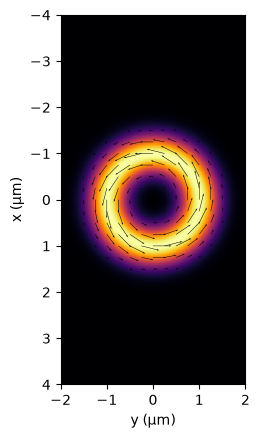

In [2]:
X = params.xx.cpu().numpy()
Y = params.yy.cpu().numpy()
R = np.sqrt(Y**2 + X**2) # Polar coordinates
Phi = np.arctan2(Y, X)

ring_radius = 1.0
ring_width = 0.3
Kx, Ky = np.zeros_like(X), np.zeros_like(Y) # Sheet currents
K = np.exp(-(R-ring_radius)**2/(2*ring_width**2)) # Ring current density
Kx = -K * np.sin(Phi) # Convert to Cartesian coordinates
Ky = K * np.cos(Phi)

fig, ax = plt.subplots(1,1)
ax.imshow(K, extent=[-params.Ly/2, params.Ly/2, params.Lx/2, -params.Lx/2], cmap='inferno')
ax.quiver(Y[::8, ::8], X[::8, ::8], Ky[::8, ::8], -Kx[::8, ::8], color='k', scale=10)
ax.set_xlabel('y (µm)')
ax.set_ylabel('x (µm)')
ax.set_aspect('equal')
plt.show()

The Forward2DCurrent class can now calculate the SQUID signal that corresponds to this ring.

In [3]:
signal = fwd.forward(Kx, Ky)

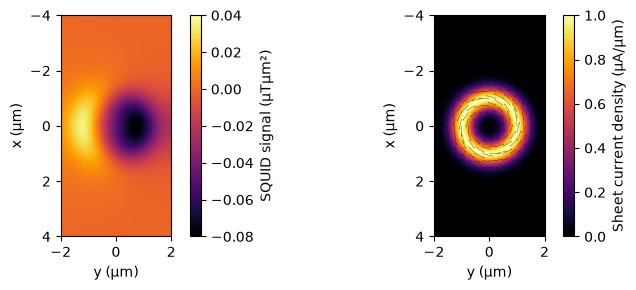

In [4]:
fig, (ax0, ax1) = plt.subplots(1,2,figsize=(8,3))
im0 = ax0.imshow(signal, extent=[-params.Ly/2, params.Ly/2, params.Lx/2, -params.Lx/2], cmap='inferno', vmin=-0.08, vmax=0.04)
ax0.set_xlabel('y (µm)')
ax0.set_ylabel('x (µm)')
ax0.set_aspect('equal')
im1 = ax1.imshow(K, extent=[-params.Ly/2, params.Ly/2, params.Lx/2, -params.Lx/2], cmap='inferno')
ax1.set_xlabel('y (µm)')
ax1.set_ylabel('x (µm)')
ax1.set_aspect('equal')
ax1.quiver(Y[::8, ::8], X[::8, ::8], Ky[::8, ::8], -Kx[::8, ::8], color='k', scale=10)
plt.colorbar(im0, ax=ax0, label='SQUID signal (µTµm²)')
plt.colorbar(im1, ax=ax1, label='Sheet current density (µA/µm)')
plt.tight_layout()
plt.show()

SOTtools uses a standard padding strategy where currents that leave the the scan area are reflected outside the scan area as part of the padding step. This means that currents intersecting the scan area are still reasonably well simulated--of course, this reflection is an *assumption*, but generally, it is far more accurate than simply assuming periodicity or zero current outside the image. To illustrate, we re-run the above example where the ring center is placed at the right upper corner.

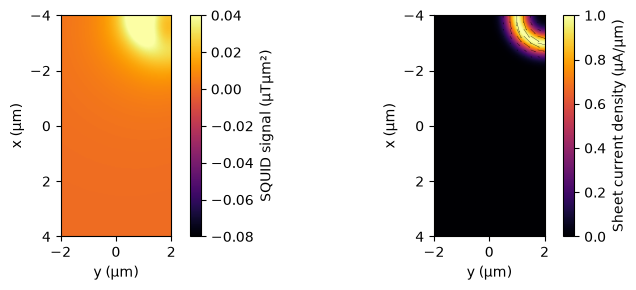

In [5]:
ring_x0 = -4
ring_y0 = 2
R = np.sqrt((Y-ring_y0)**2 + (X-ring_x0)**2) # Polar coordinates
Phi = np.arctan2(Y-ring_y0, X-ring_x0)
Kx, Ky = np.zeros_like(X), np.zeros_like(Y) # Sheet currents
K = np.exp(-(R-ring_radius)**2/(2*ring_width**2)) # Ring current density
Kx = -K * np.sin(Phi) # Convert to Cartesian coordinates
Ky = K * np.cos(Phi)

signal = fwd.forward(Kx, Ky)

fig, (ax0, ax1) = plt.subplots(1,2,figsize=(8,3))
im0 = ax0.imshow(signal, extent=[-params.Ly/2, params.Ly/2, params.Lx/2, -params.Lx/2], cmap='inferno', vmin=-0.08, vmax=0.04)
ax0.set_xlabel('y (µm)')
ax0.set_ylabel('x (µm)')
ax0.set_aspect('equal')
im1 = ax1.imshow(K, extent=[-params.Ly/2, params.Ly/2, params.Lx/2, -params.Lx/2], cmap='inferno')
ax1.set_xlabel('y (µm)')
ax1.set_ylabel('x (µm)')
ax1.set_aspect('equal')
ax1.quiver(Y[::8, ::8], X[::8, ::8], Ky[::8, ::8], -Kx[::8, ::8], color='k', scale=10)
plt.colorbar(im0, ax=ax0, label='SQUID signal (µTµm²)')
plt.colorbar(im1, ax=ax1, label='Sheet current density (µA/µm)')
plt.tight_layout()
plt.show()

So far, we have worked exclusively on a grid. However, one key feature of SOTtools is its incorporation of FEM meshes in both forward and backward problems. This keeps all modeling aware of the sample geometry. The Mesh class is responsible for generating meshes. Currently, SOTtools has a single Mesh class, SimplyConnectedCurrentMesh, which represents a geometry with a single inlet and a single outlet.

Here, we illustrate how to create such a mesh. We use the edge refinement features to create a mesh that is much more fine at the edges than in its center. For later modeling using the London equations, this is an essential feature.

In [6]:
import sottools.mesh as mesh

vertices = [
    [-4,-1.5],
    [-4, 1.5],
    [4, 1.5],
    [4, -1.5],
    [1, -1.5],
    [1, 0.5],
    [-1, 0.5],
    [-1, -1.5]
]
segments = [ # Define the edges of the mesh by connecting vertices
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 6],
    [6, 7],
    [7, 0]
]
BM = mesh.SimplyConnectedCurrentMesh.BoundaryMarker
segment_markers = [ # Specify the boundary condition at each edge
    BM.NEUMANN_IN,
    BM.DIRICHLET_RIGHT,
    BM.NEUMANN_OUT,
    BM.DIRICHLET_LEFT,
    BM.DIRICHLET_LEFT,
    BM.DIRICHLET_LEFT,
    BM.DIRICHLET_LEFT,
    BM.DIRICHLET_LEFT
]

constrictionmesh = mesh.SimplyConnectedCurrentMesh(
    vertices,
    segments,
    segment_markers,
    max_area = 0.1,
    refine_distance = 0.05
)

Just as for forward kernels, there are utility functions for the visualization of meshes.

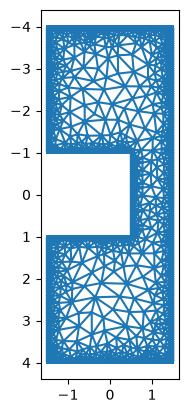

In [7]:
import sottools.utils.meshplotting as meshplotting

fig, ax = plt.subplots(1,1)
meshplotting.plot_mesh(constrictionmesh, ax)
plt.show()

On meshes, we do not specify currents directly. On a complicated mesh, making a divergence free current is extremely difficult. Instead, we specify a stream function $g$. The relation between $g$ and sheet current denisty $\mathbf{K}$ is given by:

$$\mathbf{K} = \nabla\times (g\hat{\mathbf{z}})$$

In principle, one can manually specify such stream functions, but it is much easier to generate one from known physical laws. SOTtools contains a London equation solver to generate stream functions for arbitrary thin superconductors. We illustrate this here:

Convergence: True


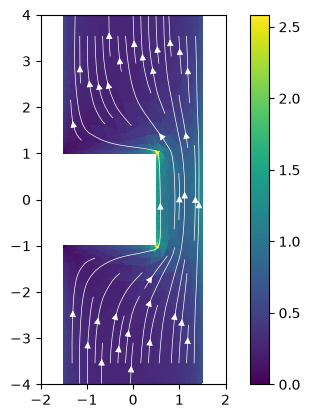

In [8]:
londonsolver = mesh.LondonSolver(
    mesh=constrictionmesh,
    Pearllength=0.3, # Pearl length = lambda^2/2d
    verbose=False
)
res = londonsolver.solve(
    left_bc = 0.0,
    right_bc = 1.0 # Boundary conditions for the streamfunction. The difference between left and right boundary conditions is the total current through the device
)

print("Convergence:", res["converged"])

fig, ax = plt.subplots(1,1)
meshplotting.streamplot(constrictionmesh, ax, res["Kx"], res["Ky"], n_grid=256)
ax.set_ylim(-4,4)
ax.set_xlim(-2,2)
plt.show()

We can use such simulations as input to generate new SQUID signals, but for this we first need to convert the currents, defined on a FEM mesh, to grid currents that can be accepted by Forward2DCurrent. This is streamlined by the MeshToGrid class.

C:\Users\LION\sottools\src\sottools\forward.py:1154: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:823.)
  torch.sparse_coo_tensor(


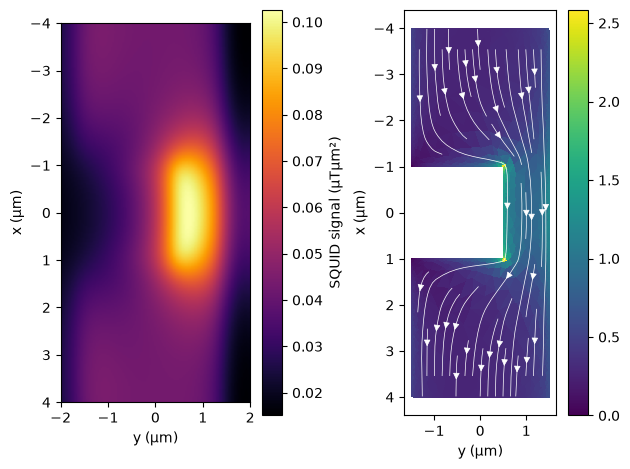

In [9]:
m2g = forward.MeshToGrid(constrictionmesh, params)
signal = fwd.forward(*m2g.streamfunction_to_currents(res["streamfunction"]))

fig, (ax0, ax1) = plt.subplots(1,2)
im0 = ax0.imshow(signal, extent=[-params.Ly/2, params.Ly/2, params.Lx/2, -params.Lx/2], cmap='inferno')
ax0.set_xlabel('y (µm)')
ax0.set_ylabel('x (µm)')
ax0.set_aspect('equal')
meshplotting.streamplot(constrictionmesh, ax1, res["Kx"], res["Ky"], n_grid=256)
ax1.set_xlabel('y (µm)')
ax1.set_ylabel('x (µm)')
plt.colorbar(im0, ax=ax0, label='SQUID signal (µTµm²)')
plt.tight_layout()
plt.show()